# **Rep. 4. Checkpoint 2. Estrategias I**
### Paola A. Figueroa Álvarez
### 11/abril/2026


## **Instrucciones**
Toma el código desarrollado en clase para las cuatro estrategias direccionales (long straddle, long strangle, bull call spread y bear put spread) y ejecútalo en tu notebook usando los precios mid reales de SPY con vencimiento 2026-04-17, obtenidos dinámicamente con yfinance (siguiendo el mismo patrón visto en clase). No necesitas escribir código nuevo: la actividad consiste en correr el código de clase con datos actualizados y presentar:

- El payoff diagram del long straddle
- El payoff diagram del long strangle
- El payoff diagram del bull call spread
- El payoff diagram del bear put spread
- Una tabla resumen con costo o prima neta, ganancia máxima, pérdida máxima y break-even(s) de cada estrategia (los valores ya se imprimen en el código de clase, basta con consolidarlos en una tabla)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

In [2]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, S0, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## **Precios reales dinámicos**

In [3]:
ticker = 'SPY'
exp    = '2026-04-17'

tk   = yf.Ticker(ticker)
hist = yf.download(ticker, period='5d', progress=False)
if isinstance(hist.columns, pd.MultiIndex):
    hist.columns = hist.columns.get_level_values(0)
S0 = float(hist['Close'].iloc[-1])

calls = tk.option_chain(exp).calls.copy()
puts  = tk.option_chain(exp).puts.copy()

def mid(df, strike):
    row = df[df['strike'] == strike].iloc[0]
    m = (row['bid'] + row['ask']) / 2
    if m == 0:
        m = row['lastPrice']
    return round(float(m), 2)

In [4]:
# Strikes de cada estrategia
K_straddle      = 680
K_strangle_call = 700
K_strangle_put  = 660
K_bull1, K_bull2 = 670, 700
K_bear1, K_bear2 = 680, 650

# Precios mid dinamicos
C_straddle = mid(calls, K_straddle)
P_straddle = mid(puts,  K_straddle)
C_strangle = mid(calls, K_strangle_call)
P_strangle = mid(puts,  K_strangle_put)
C_bull1    = mid(calls, K_bull1)
C_bull2    = mid(calls, K_bull2)
P_bear1    = mid(puts,  K_bear1)
P_bear2    = mid(puts,  K_bear2)

S_range = np.linspace(S0 * 0.88, S0 * 1.12, 500)

print(f"S0 = {S0:.2f}")
print(f"\nStraddle  : C(K={K_straddle}) = {C_straddle}  |  P(K={K_straddle}) = {P_straddle}")
print(f"Strangle  : C(K={K_strangle_call}) = {C_strangle}  |  P(K={K_strangle_put}) = {P_strangle}")
print(f"Bull Call : C(K={K_bull1}) = {C_bull1}  |  C(K={K_bull2}) = {C_bull2}")
print(f"Bear Put  : P(K={K_bear1}) = {P_bear1}  |  P(K={K_bear2}) = {P_bear2}")

S0 = 679.46

Straddle  : C(K=680) = 5.36  |  P(K=680) = 5.52
Strangle  : C(K=700) = 0.14  |  P(K=660) = 1.15
Bull Call : C(K=670) = 12.45  |  C(K=700) = 0.14
Bear Put  : P(K=680) = 5.52  |  P(K=650) = 0.53


## **Long Straddle**

Costo total     : $10.88
Break-even sup. : $690.88
Break-even inf. : $669.12
Perdida maxima  : $-10.88  (si ST = 680)
Ganancia maxima : Ilimitada


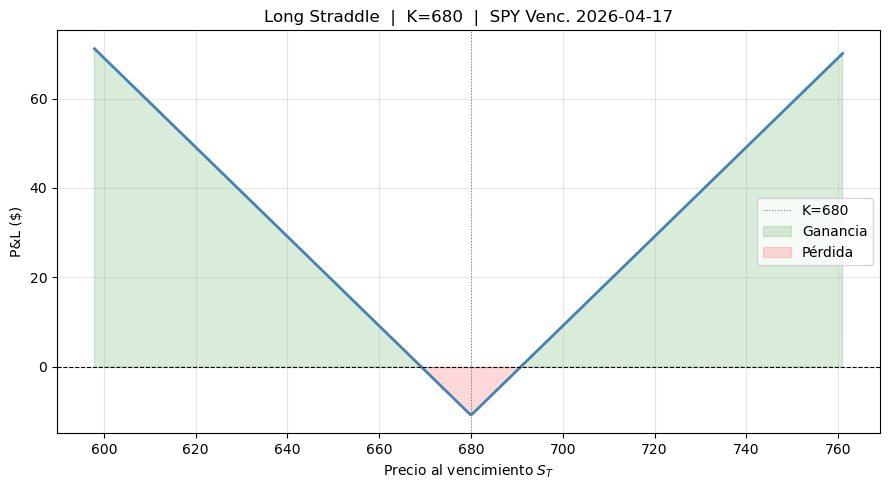

In [5]:
legs_straddle = [
    {'tipo': 'call', 'K': K_straddle, 'prima': C_straddle, 'posicion': +1},
    {'tipo': 'put',  'K': K_straddle, 'prima': P_straddle, 'posicion': +1},
]
pnl_straddle   = payoff_estrategia(S_range, legs_straddle)
costo_straddle = C_straddle + P_straddle

print(f"Costo total     : ${costo_straddle:.2f}")
print(f"Break-even sup. : ${K_straddle + costo_straddle:.2f}")
print(f"Break-even inf. : ${K_straddle - costo_straddle:.2f}")
print(f"Perdida maxima  : ${-costo_straddle:.2f}  (si ST = {K_straddle})")
print(f"Ganancia maxima : Ilimitada")

graficar_estrategia(S_range, pnl_straddle,
    f'Long Straddle  |  K={K_straddle}  |  SPY Venc. {exp}',
    S0=S0, K_lines=[(K_straddle, f'K={K_straddle}')])

## **Long Strangle**

Costo total     : $1.29  (vs $10.88 del straddle)
Break-even sup. : $701.29
Break-even inf. : $658.71
Perdida maxima  : $-1.29
Ganancia maxima : Ilimitada


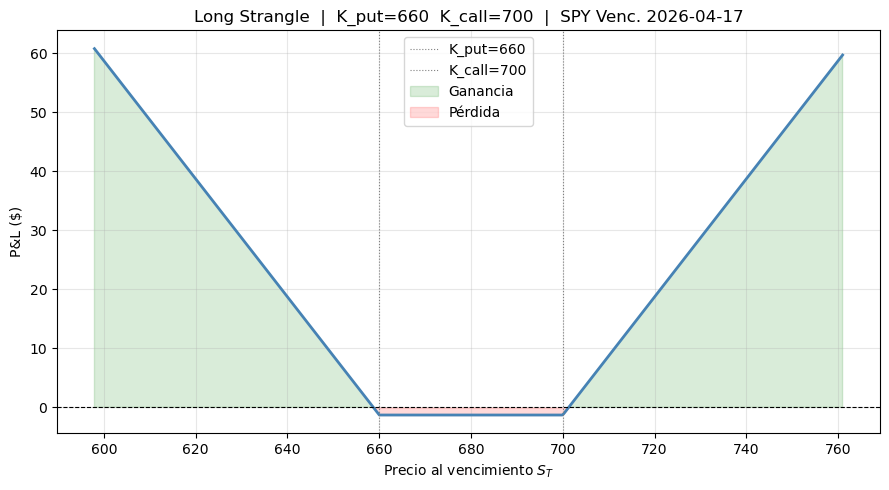

In [6]:
legs_strangle = [
    {'tipo': 'call', 'K': K_strangle_call, 'prima': C_strangle, 'posicion': +1},
    {'tipo': 'put',  'K': K_strangle_put,  'prima': P_strangle, 'posicion': +1},
]
pnl_strangle   = payoff_estrategia(S_range, legs_strangle)
costo_strangle = C_strangle + P_strangle

print(f"Costo total     : ${costo_strangle:.2f}  (vs ${costo_straddle:.2f} del straddle)")
print(f"Break-even sup. : ${K_strangle_call + costo_strangle:.2f}")
print(f"Break-even inf. : ${K_strangle_put  - costo_strangle:.2f}")
print(f"Perdida maxima  : ${-costo_strangle:.2f}")
print(f"Ganancia maxima : Ilimitada")

graficar_estrategia(S_range, pnl_strangle,
    f'Long Strangle  |  K_put={K_strangle_put}  K_call={K_strangle_call}  |  SPY Venc. {exp}',
    S0=S0, K_lines=[(K_strangle_put,  f'K_put={K_strangle_put}'),
                    (K_strangle_call, f'K_call={K_strangle_call}')])

## **Bull Call Spread**

Prima neta pagada : $12.31
Ganancia maxima   : $17.69  (si ST >= 700)
Perdida maxima    : $-12.31  (si ST <= 670)
Break-even        : $682.31


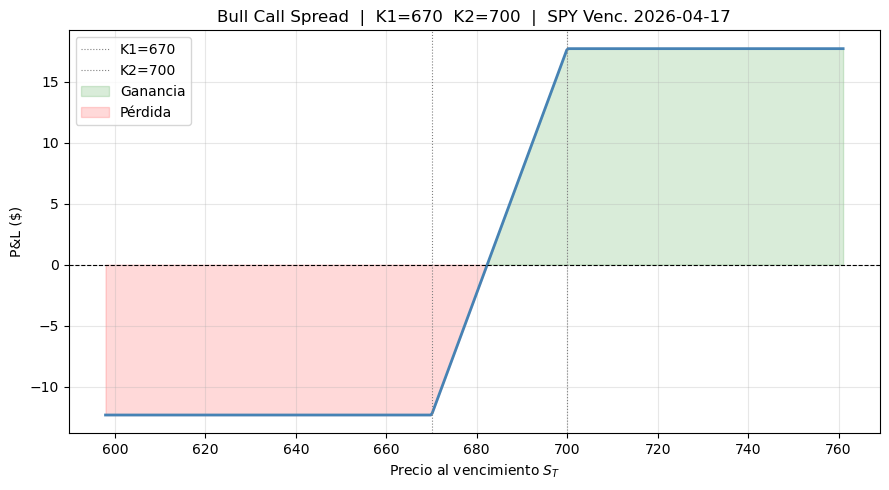

In [7]:
legs_bull = [
    {'tipo': 'call', 'K': K_bull1, 'prima': C_bull1, 'posicion': +1},
    {'tipo': 'call', 'K': K_bull2, 'prima': C_bull2, 'posicion': -1},
]
pnl_bull       = payoff_estrategia(S_range, legs_bull)
prima_neta_bull = C_bull1 - C_bull2

print(f"Prima neta pagada : ${prima_neta_bull:.2f}")
print(f"Ganancia maxima   : ${(K_bull2 - K_bull1) - prima_neta_bull:.2f}  (si ST >= {K_bull2})")
print(f"Perdida maxima    : ${-prima_neta_bull:.2f}  (si ST <= {K_bull1})")
print(f"Break-even        : ${K_bull1 + prima_neta_bull:.2f}")

graficar_estrategia(S_range, pnl_bull,
    f'Bull Call Spread  |  K1={K_bull1}  K2={K_bull2}  |  SPY Venc. {exp}',
    S0=S0, K_lines=[(K_bull1, f'K1={K_bull1}'), (K_bull2, f'K2={K_bull2}')])

## **Bear Put Spread**

Prima neta pagada : $4.99
Ganancia maxima   : $25.01  (si ST <= 650)
Perdida maxima    : $-4.99  (si ST >= 680)
Break-even        : $675.01


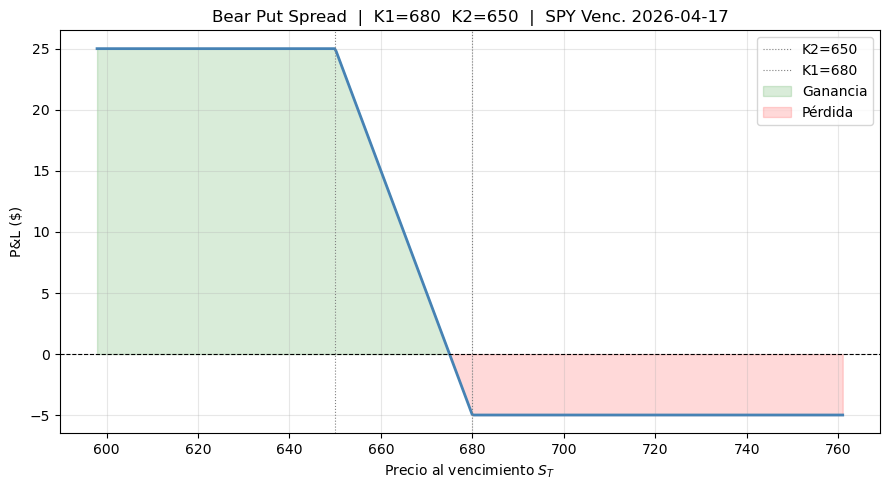

In [8]:
legs_bear = [
    {'tipo': 'put', 'K': K_bear1, 'prima': P_bear1, 'posicion': +1},
    {'tipo': 'put', 'K': K_bear2, 'prima': P_bear2, 'posicion': -1},
]
pnl_bear       = payoff_estrategia(S_range, legs_bear)
prima_neta_bear = P_bear1 - P_bear2

print(f"Prima neta pagada : ${prima_neta_bear:.2f}")
print(f"Ganancia maxima   : ${(K_bear1 - K_bear2) - prima_neta_bear:.2f}  (si ST <= {K_bear2})")
print(f"Perdida maxima    : ${-prima_neta_bear:.2f}  (si ST >= {K_bear1})")
print(f"Break-even        : ${K_bear1 - prima_neta_bear:.2f}")

graficar_estrategia(S_range, pnl_bear,
    f'Bear Put Spread  |  K1={K_bear1}  K2={K_bear2}  |  SPY Venc. {exp}',
    S0=S0, K_lines=[(K_bear2, f'K2={K_bear2}'), (K_bear1, f'K1={K_bear1}')])

## **Tabla Resumen**

In [9]:
resumen = pd.DataFrame({
    'Estrategia'       : ['Long Straddle', 'Long Strangle', 'Bull Call Spread', 'Bear Put Spread'],
    'Costo/Prima neta' : [f'${costo_straddle:.2f}',
                          f'${costo_strangle:.2f}',
                          f'${prima_neta_bull:.2f}',
                          f'${prima_neta_bear:.2f}'],
    'Ganancia max.'    : ['Ilimitada', 'Ilimitada',
                          f'${(K_bull2-K_bull1)-prima_neta_bull:.2f}',
                          f'${(K_bear1-K_bear2)-prima_neta_bear:.2f}'],
    'Perdida max.'     : [f'${-costo_straddle:.2f}',
                          f'${-costo_strangle:.2f}',
                          f'${-prima_neta_bull:.2f}',
                          f'${-prima_neta_bear:.2f}'],
    'Break-even(s)'    : [
        f'${K_straddle-costo_straddle:.2f}  /  ${K_straddle+costo_straddle:.2f}',
        f'${K_strangle_put-costo_strangle:.2f}  /  ${K_strangle_call+costo_strangle:.2f}',
        f'${K_bull1+prima_neta_bull:.2f}',
        f'${K_bear1-prima_neta_bear:.2f}'
    ]
})
resumen.index = resumen.index + 1
resumen

,Estrategia,Costo/Prima neta,Ganancia max.,Perdida max.,Break-even(s)
1,Long Straddle,$10.88,Ilimitada,$-10.88,$669.12 / $690.88
2,Long Strangle,$1.29,Ilimitada,$-1.29,$658.71 / $701.29
3,Bull Call Spread,$12.31,$17.69,$-12.31,$682.31
4,Bear Put Spread,$4.99,$25.01,$-4.99,$675.01


## **Preguntas**
Responde dentro del notebook como celdas de texto (Markdown). Las respuestas deben estar fundamentadas en tus propias gráficas con los datos reales del día que corras el código.

- 1.- Con el S0 actual, ¿cuál de las cuatro estrategias está más cerca de su zona de máxima pérdida? ¿Qué te dice eso sobre la visión de mercado que expresa?
    - Con S0 ≈ $679, el Bear Put Spread (K1=680, K2=650) está prácticamente en su zona de máxima pérdida, ya que la estrategia pierde la prima neta completa cuando ST ≥ K1=680, y el precio actual está a apenas $1 de ese umbral. Esto expresa una visión bajista que el mercado aún no confirma; si SPY se mantiene donde está o sube mínimamente, la posición expira sin valor. 

- 2.- Compara el costo total del long straddle vs. el long strangle que construiste. ¿Cuánto más barato es el strangle? ¿Cuánto más tiene que moverse SPY para que el strangle sea rentable comparado con el straddle?
    - Al igual que la teoría de la clase, donde el Strangle es más barato porque al estar OTM, requiere mayor capital para ser rentable, es decir, hay menos probabilidad de ejercicio se haga efectivo, por lo tanto hay una menor prima por pagar. En este caso,  El Strangle cuesta $0.14 vs. $5.36 del Straddle, es decir, es $5.22 más barato.  Sin embargo, esa ventaja en costo implica break-evens más alejados: el Strangle necesita que SPY se mueva hasta $701.29 al alza o $658.71 a la baja para ser rentable, mientras que el Straddle lo logra desde $690.88 y $669.12. La diferencia de $10 entre ambos break-evens superiores indica el movimiento adicioal que requiere el Strangle para empezar a ganar

- 3.- Un long straddle gana si el mercado se mueve mucho. ¿Qué pasa si compras el straddle justo después de que la IV ya subió por anticipación de un evento (por ejemplo, el día antes de earnings o de una decisión de la Fed)? ¿Sigue siendo una buena estrategia? Justifica.
    - Sería una mala estrategia porque las primas (call y put) están infladas, por lo que el costo total es mayor y los break-evens quedan más alejados. Aunque el evento ocurra y el mercado se mueva, si el movimiento no supera esos break-evens elevados la estrategia igual pierde. Incluso si el evento es muy malo o no cumple con las expectativas del mercado, la IV colapsa y el valor del straddle cae incluso si el precio se mueve, destruyendo la posición.

- 4.- El bull call spread limita la ganancia máxima comparado con un call simple. ¿Por qué alguien aceptaría ese límite voluntariamente? Da al menos dos razones.
    - Podríamos aceptar limitar la ganancia porque la veenta de K2 financia de cierta forma la compra del call en K1, reduciendo el costo neto y por tanto la pérdida máxima. Segundo, si la visión alcista es moderada es decir, se espera que SPY suba hasta cierto nivel pero no mucho más, no tiene sentido pagar la prima extra de un call simple por una ganancia ilimitada que probablemente no se va a alcanzar.

- 5.- Si tienes un bull spread abierto y SPY supera K2 antes del vencimiento, ¿tiene sentido cerrar la posición o esperar al vencimiento? ¿Qué factores considerarías para decidir?
    - Podría convenir cerrar la posición y tomar utilidades, ya que el spread ya alcanzó casi su ganancia máxima teórica pero aún carga riesgo. Para poder decidir, deveriamos considerar el valor del tiempo (prima - valor intrínseco, lo que significa puro costo del tiempo y la volatilidad, sin ningún valor de ejercicio inmediato), qué tan cerca está el vencimiento, y el costo de transacción del cierre. Si el vencimiento es inminente y el spread cotiza cerca de su valor máximo (K2−K1−prima neta), cerrarlo elimina el riesgo sin sacrificar casi nada.

- 6.- ¿Cómo afecta un aumento de IV a un bull spread comparado con un long straddle? ¿Cuál de las dos posiciones es más sensible a cambios en volatilidad implícita y por qué?
    - Un aumento de IV beneficia al Long Straddle (vega positiva alta en ambas partes) y tiene un efecto casi neutro en el Bull Call Spread, cuyas vegas se cancelan parcialmente entre el long call (vega +) y el short call (vega −). El Straddle es mucho más sensible a cambios en volatilidad implícita precisamente porque su diseño apuesta a movimiento, mientras que el spread acota tanto ganancia como exposición a vega.

- 7.- En términos de griegas (delta, gamma, vega, theta), ¿cuál es la diferencia principal entre comprar un call simple y comprar un bull call spread? ¿Qué griega cambia más drásticamente entre las dos estructuras?  
    - La diferencia principal es que el Bull Call Spread tiene vega y gamma significativamente menores que un call simple, porque la pata corta (short call en K2) las neutraliza parcialmente. La griega que cambia más drásticamente entre ambas estructuras es vega: el call simple tiene vega positiva plena, mientras que el spread la reduce casi a cero cuando el precio está entre K1 y K2, haciendo que la posición sea mucho menos sensible a cambios en volatilidad implícita y más dependiente de la dirección del subyacente.